In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nudratabbas/software-developer-salary-prediction-dataset")
print(path)

c:\stuff\Code\Python\Machine-Learning\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\user\.cache\kagglehub\datasets\nudratabbas\software-developer-salary-prediction-dataset\versions\1


In [18]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error as MSE, mean_absolute_error as MAE, accuracy_score 
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor

In [3]:
data = pd.read_csv(os.path.join(path, os.listdir(path)[1]))
data.head()

,experience,country,education,languages,frameworks,company_size,salary_usd
0,10,Singapore,Bachelors,"JavaScript, Go","Spring, Express",1-10,68491
1,13,USA,Some College,"PHP, Java","Flask, Ruby on Rails",51-200,120045
2,28,India,Some College,"JavaScript, C#","Vue, Spring",51-200,87811
3,16,Brazil,Bachelors,"Ruby, JavaScript","React, Spring",201-1000,99426
4,20,Singapore,PhD,"Java, Java","Laravel, Laravel",201-1000,108251


In [4]:
# print(len(data.select_dtypes(include="str").columns))

# for i in data.select_dtypes(include="object").columns:
#     print(i.upper())
#     print(f"Number of unique elements {data[i].nunique()}")    
#     print(f"unique elements: {data[i].unique()}\n",)    

# data["company_size"].unique()
data.describe()
# data.isna().sum()

,experience,salary_usd
count,10000.000000,10000.000000
mean,19.770100,131110.684200
std,11.880234,46550.853186
min,0.000000,12032.000000
25%,9.000000,97398.250000
50%,20.000000,129706.000000
75%,30.000000,164090.250000
max,40.000000,280900.000000


In [5]:

mlb_lang=  MultiLabelBinarizer()
mlb_frame = MultiLabelBinarizer()

lang_encoded = pd.DataFrame(
    mlb_lang.fit_transform(data["languages"].str.split(", ")),
    columns=mlb_lang.classes_,
    index = data.index
)
frame_encoded = pd.DataFrame(
    mlb_frame.fit_transform(data["frameworks"].str.split(", ")),
                            columns=mlb_frame.classes_,
                            index = data.index
)

data.drop(columns=["languages","frameworks"], inplace=True)
data = pd.concat([data, lang_encoded, frame_encoded], axis=1)

size_order = {"1-10": 1, "11-50": 2 , "51-200": 3, "201-1000": 4, "1001-5000": 5, "5000+" : 6}
data["company_size"] = data["company_size"].map(size_order)

edu_order = {"High School": 1, "Some College": 2, "Bachelors": 3, "Masters": 4, "PhD": 5}
data["education"] = data["education"].map(edu_order)

data.head()

,experience,country,education,company_size,salary_usd,C#,C++,Go,Java,JavaScript,...,ASP.NET,Angular,Django,Express,Flask,Laravel,React,Ruby on Rails,Spring,Vue
0,10,Singapore,3,1,68491,0,0,1,0,1,...,0,0,0,1,0,0,0,0,1,0
1,13,USA,2,3,120045,0,0,0,1,0,...,0,0,0,0,1,0,0,1,0,0
2,28,India,2,3,87811,1,0,0,0,1,...,0,0,0,0,0,0,0,0,1,1
3,16,Brazil,3,4,99426,0,0,0,0,1,...,0,0,0,0,0,0,1,0,1,0
4,20,Singapore,5,4,108251,0,0,0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [6]:
data_dummified = pd.get_dummies(data, columns=["country"])
# data_dummified.drop(columns=["languages", "frameworks"], inplace=True)
data_dummified.head()

,experience,education,company_size,salary_usd,C#,C++,Go,Java,JavaScript,PHP,...,country_Australia,country_Brazil,country_Canada,country_France,country_Germany,country_India,country_Japan,country_Singapore,country_UK,country_USA
0,10,3,1,68491,0,0,1,0,1,0,...,False,False,False,False,False,False,False,True,False,False
1,13,2,3,120045,0,0,0,1,0,1,...,False,False,False,False,False,False,False,False,False,True
2,28,2,3,87811,1,0,0,0,1,0,...,False,False,False,False,False,True,False,False,False,False
3,16,3,4,99426,0,0,0,0,1,0,...,False,True,False,False,False,False,False,False,False,False
4,20,5,4,108251,0,0,0,1,0,0,...,False,False,False,False,False,False,False,True,False,False


# Data Split and Scaling

In [7]:

X = data_dummified.drop("salary_usd", axis=1).values
y = data_dummified["salary_usd"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

def regressionMetrics(model, X_train, X_test, y_pred):
    mse = MSE(y_test, y_pred)
    root_MSE = np.sqrt(mse)
    mae = MAE(y_test, y_pred)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)
    score = model.score(X_test, y_test)
    print(f"""  
    Score: {score:.4f}
    Train R²: {train_score:.4f}
    Test R²:  {test_score:.4f}
    SCORE: {score}
    MSE: {mse}
    RMSE: {root_MSE}
    MAE: {mae}""")



# Models

In [8]:
linreg = LinearRegression()
dt = DecisionTreeRegressor(max_depth=10, min_samples_leaf=5, random_state=5)
br = BaggingRegressor(estimator=dt,  oob_score=True, n_estimators=300, n_jobs=-1)
rf = RandomForestRegressor(n_estimators=400, min_samples_leaf=5, random_state=5)


# Random Forest

In [9]:
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("RANDOM FOREST")
regressionMetrics(rf, X_train, X_test, y_pred_rf)

RANDOM FOREST
  
    Score: 0.8707
    Train R²: 0.9248
    Test R²:  0.8707
    SCORE: 0.8707443029041153
    MSE: 288295711.72770447
    RMSE: 16979.27300350944
    MAE: 13713.535645994818


## Feature Importance

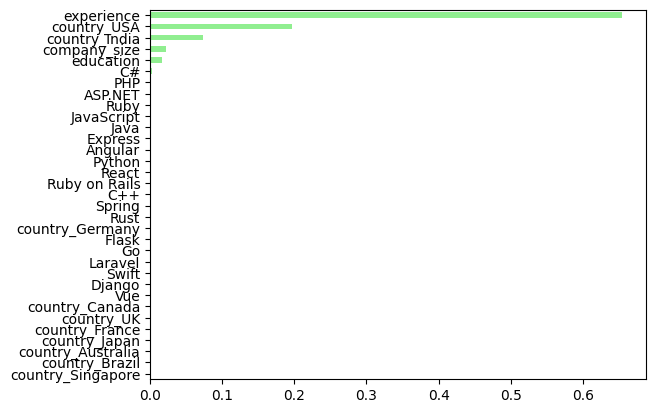

In [10]:
importance_rf = pd.Series(rf.feature_importances_, index=data_dummified.drop("salary_usd", axis=1).columns)

sorted_importances = importance_rf.sort_values()

sorted_importances.plot(kind="barh", color="lightgreen")
plt.show()

# Bagging Regressor

In [11]:
br.fit(X_train, y_train)
y_pred_br = br.predict(X_test)
print("BAGGING REGRESSOR")
regressionMetrics(br, X_train, X_test, y_pred_br)
print(f"OOB Score: {br.oob_score_}")

BAGGING REGRESSOR
  
    Score: 0.8720
    Train R²: 0.9090
    Test R²:  0.8720
    SCORE: 0.8719718518789225
    MSE: 285557750.358697
    RMSE: 16898.454081918175
    MAE: 13720.093472113356
OOB Score: 0.8724874816266304


# Linear Regression

In [12]:
# y_train_log = np.log(y_train)

linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)
# y_pred = np.exp(y_pred_log)
print("LINEAR REGRESSION")
regressionMetrics(linreg, X_train_scaled, X_test_scaled, y_pred)


LINEAR REGRESSION
  
    Score: 0.8701
    Train R²: 0.8725
    Test R²:  0.8701
    SCORE: 0.8701200358669585
    MSE: 289688095.3040489
    RMSE: 17020.22606501009
    MAE: 13957.301278051322


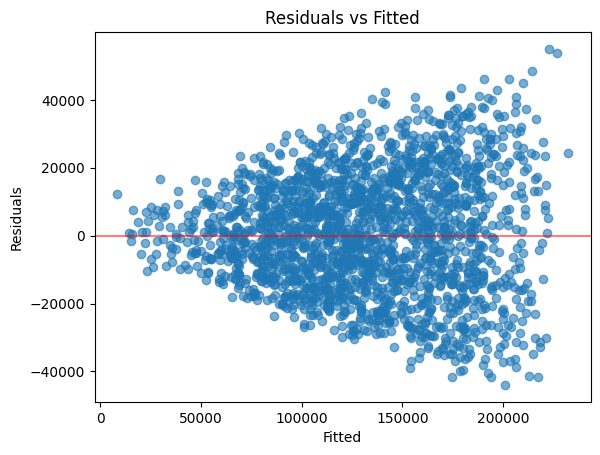

In [13]:
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color="red", alpha=0.5)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()

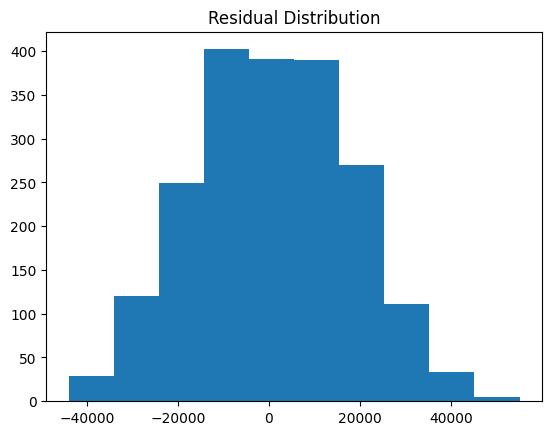

In [16]:
plt.hist(residuals, bins=10)
plt.title("Residual Distribution")
plt.show()

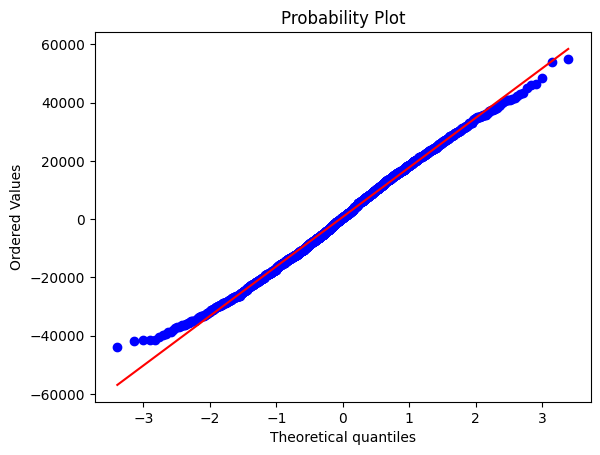

In [19]:
stats.probplot(residuals, dist="norm", plot=plt)
plt.show()

# Decision Tree Regressor

In [13]:
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("DECISION TREE REGRESSOR")
regressionMetrics(dt, X_train, X_test, y_pred_dt)

DECISION TREE REGRESSOR
  
    Score: 0.8515
    Train R²: 0.9027
    Test R²:  0.8515
    SCORE: 0.8515496376587016
    MSE: 331108058.1281615
    RMSE: 18196.374862267527
    MAE: 14578.267064384167


Predictions are off by 14k According to the MAE